<a href="https://colab.research.google.com/github/Valrite/Digital-Image-Processing-Labs/blob/main/Lab5/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

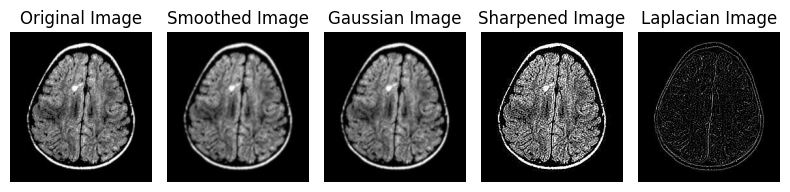

In [ ]:
"""
Prg 5. Demonstrate Smoothing, Sharpening and Noise removal for a poor quality image.
"""

#import the necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load a grayscale image
img = cv2.imread("images/scan.jpeg",0)

# define Smoothing Filter (Averaging Kernel)
smoothing_filter = np.array([[1,1,1],
                            [1,1,1],
                            [1,1,1]]) * (1/9)

# define Gaussian filter
gaussian_filter = np.array([[1,2,1],
                            [2,4,2],
                            [1,2,1]]) * (1/16)

# define Sharpening Filter
sharpening_filter = np.array([[0,-1,0],
                             [-1,5,-1],
                             [0,-1,0]])

lfilter = np.array([[0,1,0],
                    [1,-4,1],
                    [0,1,0]])
# Apply the filters using cv2.filter2D
smoothed_image = cv2.filter2D(img, -1, smoothing_filter)
gaussian_filtered = cv2.filter2D(img,-1, gaussian_filter)
sharpened_image = cv2.filter2D(img, -1, sharpening_filter)
L = cv2.filter2D(img, -1, lfilter)
# Display results
fig, axes = plt.subplots(1, 5, figsize=(8, 4))

titles = ["Original Image", "Smoothed Image", "Gaussian Image", "Sharpened Image","Laplacian Image"]
images = [img, smoothed_image, gaussian_filtered, sharpened_image,L]

for i in range(5):
      axes[i].imshow(images[i], cmap='gray')
      axes[i].set_title(titles[i])
      axes[i].axis("off")

plt.tight_layout()
plt.show()

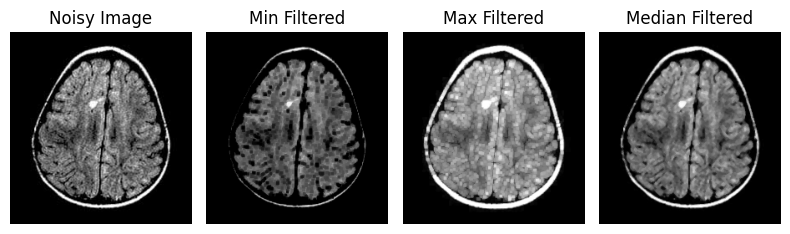

In [ ]:

#=========ORDER STATISTICS FILTERS===================
def order_stat_filter(img, ksize, mode="median"):
    pad = ksize // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+ksize,j:j+ksize]           # define window

            if mode == "min":
                output[i, j] = np.min(window)

            elif mode == "max":
                output[i, j] = np.max(window)

            elif mode == "median":
                output[i, j] = np.median(window)

    return output

import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load a grayscale image
img = cv2.imread("images/salt.jpg",0)
# Read noisy image in grayscale

min_filtered = order_stat_filter(img, 3, 'min')
max_filtered = order_stat_filter(img, 3, 'max')
median_filtered = order_stat_filter(img, 3, 'median')

# Display results
# Display results


<h1>Spatial Filters</h1>
Spatial filtering techniques involve convolving a filter across the image to modify pixel values based on their neighbors, enhancing or suppressing certain features like edges, noise, or blurring effects. Spatial filtering is widely used in image processing for tasks such as smoothing, sharpening, and edge detection.

<h4>Steps</h4>
<ul>
<li>Choose a filter.
<li>Apply the filter on each pixel neighbourhood in the image (convolution)
</ul>

<h3>Examples of filters</h3>
<ul>
<li> For blurring/smoothing
<ul>
<li> Box filter/Averaging filter - for blurring images

$$ K = \frac{1}{9} \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}$$

<li> Guassian filter - for blurring images while preseving edges
$$K = \frac{1}{16}
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}$$
</ul>
<li>for Sharpening
$$K = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

<hr>

<h3>Applying the filter to the image</h3>
The cv2.filter2D() function in OpenCV is used for applying a custom filter (kernel) to an image using convolution. It allows you to apply various spatial filtering techniques like blurring, sharpening, edge detection, and embossing by defining a kernel.

<h3>Syntax</h3>
```
dst = cv2.filter2D(src, ddepth, kernel)
```
<ul>
<li>src - The input image (grayscale or color).
<li>ddepth - The desired depth of the output image (-1 means same as source).
<li>kernel - The custom filter (convolution kernel)
</ul>





<h1>Min, Max, and Median Filters</h1>

<div class="card">
    <h2>Min Filter</h2>
    <p>
        The <b>min filter</b> replaces each pixel with the smallest value
        in its neighborhood window.
    </p>
    <p>
        It is useful for removing <b>salt noise</b> (bright pixels) and is
        equivalent to <b>morphological erosion</b>.
    </p>
    <p><code>I'(x,y) = min(I<sub>neighbourhood</sub>(i,j))</code></p>
</div>

<div class="card">
    <h2>Max Filter</h2>
    <p>
        The <b>max filter</b> replaces each pixel with the largest value
        in the neighborhood window.
    </p>
    <p>
        It helps remove <b>pepper noise</b> (dark pixels) and is equivalent
        to <b>morphological dilation</b>.
    </p>
    <p><code>I'(x,y) = max(I<sub>neighbourhood</sub>(i,j))</code></p>
</div>

<div class="card">
    <h2>Median Filter</h2>
    <p>
        The <b>median filter</b> replaces each pixel with the median value
        of the neighborhood window.
    </p>
    <p>
        It is very effective for removing <b>salt-and-pepper noise</b> while
        preserving edges.
    </p>
    <p><code>I'(x,y) = median(I<sub>neighbourhood</sub>(i,j))</code></p>
</div>
